In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import torch
import torch.nn as nn
import yaml
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from dataset import load_data
from episode_sampler import EpisodeSampler
from protonet import ProtoNet
from encoder import Encoder
from utils import deterministic, select_fixed_subset, plot_accuracies_model
from protonet_utils import evaluate_domains_protonet, train_protonet

In [3]:
with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Train

In [ ]:
data = "Mnist"
experiment_parameters = config["protonet"]
lr = experiment_parameters["lr"]
in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]
epochs = experiment_parameters["epochs"]
episodes = experiment_parameters["episodes"]
n_way = experiment_parameters["n_way"]
k_shot = experiment_parameters["k_shot"]
q_query = experiment_parameters["q_query"]

train_images, train_labels = load_data("train", config[data]["dataset_output_dir"])
val_images, val_labels = load_data("val", config[data]["dataset_output_dir"])

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
model = ProtoNet(encoder)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_sampler = EpisodeSampler(images=train_images, labels=train_labels,
                               n_way=n_way, k_shot=k_shot, q_query=q_query)

val_sampler = EpisodeSampler(images=val_images, labels=val_labels,
                             n_way=n_way, k_shot=k_shot, q_query=q_query)

mnist_vis_images, mnist_vis_labels = select_fixed_subset(val_images, val_labels, samples_per_class=100, seed=config["xtra"]["seed"])

In [ ]:
deterministic(config["xtra"]["seed"])
protonet_history, emb_labels = train_protonet(
    model=model,
    train_sampler=train_sampler,
    val_sampler=val_sampler,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs,
    episodes=episodes,
    tsne_images=mnist_vis_images,
    tsne_labels=mnist_vis_labels,
    tsne_dir="../images",
)

In [ ]:
path = "../models/weights/protonet.pth"
model.save(path)

In [ ]:
path = "../results/protonet_history.yaml"

tsne_path = "../results/protonet_tsne.npz"
tsne_embeddings = np.stack([emb_2d for emb_2d, _ in emb_labels], axis=0)
tsne_labels = np.stack([y for _, y in emb_labels], axis=0)
snapshot_epochs = np.array([0, epochs // 2, epochs], dtype=np.int32)[:len(emb_labels)]
np.savez_compressed(
    tsne_path,
    embeddings=tsne_embeddings,
    labels=tsne_labels,
    epochs=snapshot_epochs,
)

with open(path, "w") as f:
    yaml.dump(protonet_history, f)

### Train history

In [4]:
path = "../results/protonet_history.yaml"
with open(path, "r") as f:
    protonet_history = yaml.safe_load(f)

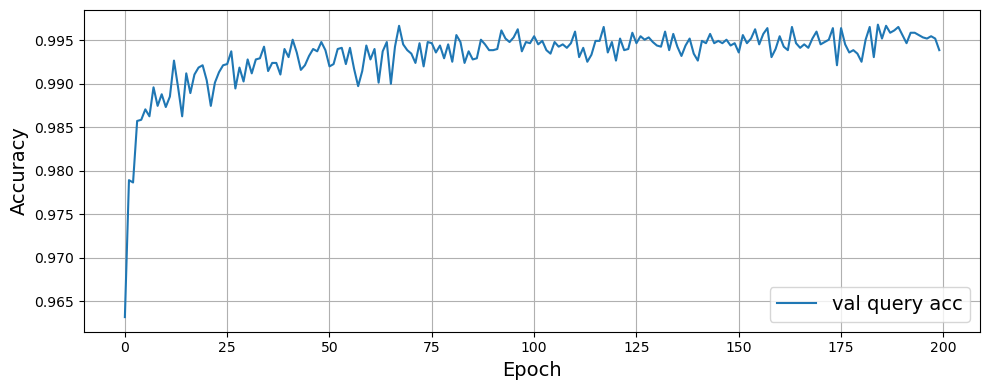

       Support Accuracy  Query Accuracy
Train            0.9996        0.998400
Val              0.9972        0.993867


In [5]:
fontsize = 14
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(protonet_history["val_query_acc"], label="val query acc")
ax.set_xlabel("Epoch", fontsize=fontsize)
ax.set_ylabel("Accuracy", fontsize=fontsize)
ax.legend(fontsize=fontsize)
ax.grid(True)

fig.tight_layout()
path = "../images/protonet/protonet_training.png"
os.makedirs(os.path.dirname(path), exist_ok=True)
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()


df = pd.DataFrame({
    "Support Accuracy": [protonet_history["train_support_acc"][-1], protonet_history["val_support_acc"][-1]],
    "Query Accuracy": [protonet_history["train_query_acc"][-1], protonet_history["val_query_acc"][-1]],
}, index=["Train", "Val"])
print(df)


#### Tsne

In [ ]:
tsne_path = "../results/protonet_tsne.npz"
with np.load(tsne_path) as data:
    tsne_embeddings = data["embeddings"]
    tsne_labels = data["labels"]
    snapshot_epochs = data["epochs"]

fig, axes = plt.subplots(1, tsne_embeddings.shape[0], figsize=(12, 5), sharey=True)
if tsne_embeddings.shape[0] == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.scatter(
        tsne_embeddings[i, :, 0],
        tsne_embeddings[i, :, 1],
        c=tsne_labels[i],
        cmap="tab10",
        s=10,
        alpha=0.8,
    )
    ax.set_title(f"Epoch {int(snapshot_epochs[i])}")
    ax.set_xlabel("t-SNE dim 1", fontsize=14)
    if i == 0:
        ax.set_ylabel("t-SNE dim 2", fontsize=14)
    if i == len(axes) - 1:
        fig.colorbar(ax.collections[0], ax=ax, ticks=list(range(10)), label="Class")
    ax.grid(True)

fig.tight_layout()
path = "../images/protonet/protonet_training_tsnes.png"
os.makedirs(os.path.dirname(path), exist_ok=True)
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

### Eval

In [ ]:
path = "../models/weights/protonet.pth"
experiment_parameters = config["protonet"]
in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]
encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
model = ProtoNet(encoder)
model.load(path, device)

In [ ]:
ks = [1, 2, 4, 8, 16]
q = 10
n_way = experiment_parameters["n_way"]
episodes = experiment_parameters["evalute_episodes"]

accuracies = {"Mnist": [], "Mnist-M": [], "Svhn": []}

data = "Mnist"
test_mnist_images, test_mnist_labels = load_data("test", config[data]["dataset_output_dir"])

data = "Mnist_M"
test_mnist_m_images, test_mnist_m_labels = load_data("test", config[data]["dataset_output_dir"])

data = "Svhn"
test_svhn_images, test_svhn_labels = load_data("test", config[data]["dataset_output_dir"])

test_data = {"Mnist": (test_mnist_images, test_mnist_labels),
             "Mnist-M": (test_mnist_m_images, test_mnist_m_labels),
             "Svhn": (test_svhn_images, test_svhn_labels)}


In [ ]:
accuracies = evaluate_domains_protonet(model=model,test_data=test_data, n_way=n_way,
                              ks=ks, q=q, episodes=episodes, device=device)

for k in ks:
    print(f"K={k} Accuracy: Mnist={accuracies['Mnist'][ks.index(k)]:.4f}, "
          f"Mnist-M={accuracies['Mnist-M'][ks.index(k)]:.4f}, "
          f"Svhn={accuracies['Svhn'][ks.index(k)]:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax = plot_accuracies_model(ks, accuracies, ax)
path = "../images/protonet/acc_vs_ks.png"
os.makedirs(os.path.dirname(path), exist_ok=True)
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
samples_per_class = 100

fixed_images_labels = {}

for domain in test_data:
    images, labels = test_data[domain]
    fixed_images, fixed_labels = select_fixed_subset(
        images,
        labels,
        samples_per_class=samples_per_class,
        seed=config["xtra"]["seed"]
    )
    fixed_images_labels[domain] = (fixed_images, fixed_labels)

#embeddings
model.eval()
embeddings_labels = {}

with torch.no_grad():
    for domain in fixed_images_labels:
        images, labels = fixed_images_labels[domain]
        images = images.to(device)
        embeddings = model.encoder(images).cpu().numpy()
        labels = labels.cpu().numpy()
        embeddings_labels[domain] = (embeddings, labels)
all_embeddings = []
all_labels = []
all_domains = []

for domain in embeddings_labels:
    embeddings, labels = embeddings_labels[domain]
    all_embeddings.append(embeddings)
    all_labels.append(labels)
    all_domains.extend([domain] * len(labels))

all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
all_domains = np.array(all_domains)

#tsne
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    learning_rate="auto"
)
tsne_embeddings = tsne.fit_transform(all_embeddings)

fontsize = 14
cmap = plt.cm.get_cmap("tab10", 10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

#subplot 1: domain color
domain_colors = {
    "Mnist": "tab:blue",
    "Mnist-M": "tab:orange",
    "Svhn": "tab:green"
}

for domain in np.unique(all_domains):
    domain_mask = all_domains == domain

    axes[0].scatter(
        tsne_embeddings[domain_mask, 0],
        tsne_embeddings[domain_mask, 1],
        color=domain_colors[domain],
        alpha=0.7,
        s=20,
        label=domain
    )

axes[0].set_title("t-SNE colored by domain")
axes[0].set_xlabel("t-SNE Dimension 1", fontsize=fontsize)
axes[0].set_ylabel("t-SNE Dimension 2", fontsize=fontsize)
axes[0].grid(True)
axes[0].legend(title="Domain")

#subplot 2: class color
scatter = axes[1].scatter(
    tsne_embeddings[:, 0],
    tsne_embeddings[:, 1],
    c=all_labels,
    cmap=cmap,
    vmin=0,
    vmax=9,
    alpha=0.7,
    s=20
)

axes[1].set_title("t-SNE colored by class")
axes[1].set_xlabel("t-SNE Dimension 1", fontsize=fontsize)
axes[1].grid(True)

cbar = fig.colorbar(scatter, ax=axes[1], ticks=list(range(10)))
cbar.set_label("Class")

fig.tight_layout()
path = "../images/protonet/tsnes_domain_class.png"
os.makedirs(os.path.dirname(path), exist_ok=True)
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()